![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E11 - Uso de herramientas y descripciones
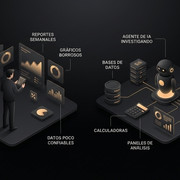

*Figura E11. Tool use: funcion Python, schema y decision del modelo.*

## Escenario

Tu empresa necesita automatizar un **reporte semanal de ventas**.

Este notebook estudia una pieza central de un agente: la **herramienta**.

La clase avanza asi:

```text
Teoria corta -> diagrama -> codigo -> ejecutar -> leer salida -> aplicar el concepto
```

Objetivo: entender que una herramienta no es solo una funcion. Es una funcion con contrato, descripcion y responsabilidad clara.


## Mapa conceptual

| Concepto | Pregunta guia | En este notebook |
|---|---|---|
| Herramienta | ¿Qué acción externa puede hacer el agente? | Buscar ventas o calcular. |
| Contrato | ¿Qué entra y qué sale? | Parametros claros y salida predecible. |
| Seguridad | ¿Qué puede salir mal? | `eval()` ejecuta demasiado. |
| Descripcion | ¿Cómo decide el modelo usarla? | Descripcion vaga vs descripcion precisa. |
| OpenAI | ¿Qué le mandamos al modelo? | Mensajes + schema de herramientas. |

Diagrama general:

```text
Usuario
  |
  v
Modelo de IA
  |
  | decide herramienta según descripcion
  v
Schema de herramienta  ---->  Funcion Python real
                                  |
                                  v
                              Resultado
```

Importante: a OpenAI no le mandamos la funcion Python completa. Le mandamos una **descripcion estructurada** de la herramienta. La funcion real la ejecutamos nosotros.


## Bloque 1 - Una calculadora insegura

Empezamos con un ejemplo simple para entender por que no cualquier funcion es una buena herramienta.

`eval()` funciona, pero ejecuta expresiones de Python. Eso lo hace peligroso con input no confiable.

Que mirar al ejecutar:

- la funcion calcula;
- pero tambien acepta expresiones que no son una simple suma o multiplicacion.


In [ ]:
def calculadora_insegura(expresion: str):
    """Calculadora insegura: evalua una expresion de Python."""
    return eval(expresion)


resultado = calculadora_insegura("12 * 30 + 20 * 12")
print(f"calculadora_insegura('12 * 30 + 20 * 12') -> {resultado}")

expresion_rara = "__import__('math').sqrt(16)"
resultado_raro = calculadora_insegura(expresion_rara)
print(f"calculadora_insegura(expresion_rara) -> {resultado_raro}")
print("Esto funciono porque eval puede ejecutar expresiones arbitrarias de Python.")


## Bloque 2 - Convertir una funcion en herramienta segura

Una herramienta productiva debe limitar que puede hacer.

Tabla de diseno:

| Parte | Decision |
|---|---|
| Entrada | `operacion`, `a`, `b` |
| Operaciones permitidas | sumar, restar, multiplicar, dividir |
| Error esperado | division por cero u operacion no soportada |
| Salida | numero `float` |

Diagrama:

```text
operacion + a + b
      |
      v
validar operacion
      |
      v
calcular resultado
      |
      v
numero final
```


In [ ]:
def calculadora_segura(operacion: str, a: float, b: float) -> float:
    """Calculadora segura con operaciones explicitas."""
    if operacion == "sumar":
        return a + b
    if operacion == "multiplicar":
        return a * b
    if operacion == "restar":
        return a - b
    if operacion == "dividir":
        if b == 0:
            raise ValueError("no se permite dividir por cero")
        return a / b
    raise ValueError(f"operacion no soportada: {operacion}")


print(f"calculadora_segura('multiplicar', 12, 30) -> {calculadora_segura('multiplicar', 12, 30)}")
print(f"calculadora_segura('sumar', 360, 240) -> {calculadora_segura('sumar', 360, 240)}")


## Bloque 3 - Herramienta local del reporte de ventas

Ahora volvemos al escenario del reporte semanal.

Primero definimos la herramienta Python real. Todavia no aparece OpenAI.

```text
buscar_datos_ventas(semana)
      |
      v
filtra datos locales
      |
      v
lista de filas de ventas
```

Esta es la herramienta que nosotros podemos ejecutar localmente.


In [ ]:
DATOS_VENTAS = [
    {"semana": "2026-W22", "producto": "Pro", "unidades": 12, "precio_unitario": 30},
    {"semana": "2026-W22", "producto": "Starter", "unidades": 20, "precio_unitario": 12},
    {"semana": "2026-W22", "producto": "Enterprise", "unidades": 3, "precio_unitario": 120},
]


def buscar_datos_ventas(semana: str) -> list[dict]:
    """Herramienta real de Python: busca ventas por semana."""
    return [fila for fila in DATOS_VENTAS if fila["semana"] == semana]


print(f"buscar_datos_ventas('2026-W22') -> {buscar_datos_ventas('2026-W22')}")


## Bloque 4 - Lo que le mandamos a OpenAI

OpenAI no recibe directamente la funcion `buscar_datos_ventas`.

Recibe un schema con:

| Campo | Para que sirve |
|---|---|
| `name` | Nombre de la herramienta. |
| `description` | Explica cuando usarla. |
| `parameters` | Define que argumentos puede pedir el modelo. |

Diagrama:

```text
Funcion Python real
buscar_datos_ventas()

        NO se manda completa a OpenAI
        
Schema de herramienta
nombre + descripcion + parametros

        SI se manda a OpenAI
```

La descripcion es clave: si es vaga, el modelo puede no entender cuando usarla.


In [ ]:
descripcion_vaga = "Obtiene cosas."

descripcion_precisa = (
    "Obtiene filas de ventas semanales para una semana ISO dada. "
    "Usar cuando el usuario pide datos de ventas o un reporte semanal de ventas."
)


def construir_schema_buscar_ventas(descripcion: str) -> dict:
    """Construye el schema que se envia a OpenAI para describir la herramienta."""
    return {
        "type": "function",
        "function": {
            "name": "buscar_datos_ventas",
            "description": descripcion,
            "parameters": {
                "type": "object",
                "properties": {
                    "semana": {
                        "type": "string",
                        "description": "Semana ISO del reporte, por ejemplo 2026-W22.",
                    }
                },
                "required": ["semana"],
            },
        },
    }


schema_vago = construir_schema_buscar_ventas(descripcion_vaga)
schema_preciso = construir_schema_buscar_ventas(descripcion_precisa)

print("Schema con descripcion vaga:")
print(schema_vago)
print()
print("Schema con descripcion precisa:")
print(schema_preciso)


## Bloque 5 - Cargar OpenAI API key

Ejecuta esta celda solo si vas a probar la parte con OpenAI real.

La clave no se imprime en pantalla y queda cargada solo en esta sesion del notebook.


In [ ]:
import os
import getpass

api_key = getpass.getpass("Ingresá tu OpenAI API key: ")
os.environ["OPENAI_API_KEY"] = api_key
print("OPENAI_API_KEY cargada en esta sesion.")


## Bloque 6 - Llamar a OpenAI con herramientas

Ahora se ve la separacion completa:

```text
1. Mensaje del usuario
2. Schema de herramientas
3. OpenAI decide si llama una herramienta
4. Nosotros leemos `tool_calls`
```

En esta celda vamos a comparar la descripcion vaga contra la descripcion precisa.

Si no cargaste API key, la celda muestra un mensaje y no bloquea la clase.


In [ ]:
import os
import subprocess
import sys


def obtener_clase_openai():
    """Importa OpenAI. En Colab, intenta instalar el paquete si no existe."""
    try:
        from openai import OpenAI
        return OpenAI
    except ImportError:
        print("No encuentro el paquete openai. Intento instalarlo en esta sesion...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "openai"])
            from openai import OpenAI
            return OpenAI
        except Exception as error:
            print("No pude instalar/importar openai automaticamente.")
            print("Ejecuta en una celda aparte: !pip install -U openai")
            print(f"Error original: {type(error).__name__}: {error}")
            return None


def crear_cliente_openai():
    """Crea el cliente de OpenAI si hay API key disponible."""
    clave_api = os.getenv("OPENAI_API_KEY")
    if not clave_api:
        print("Configura OPENAI_API_KEY para ejecutar la demo real con OpenAI.")
        return None

    OpenAI = obtener_clase_openai()
    if OpenAI is None:
        return None

    return OpenAI(api_key=clave_api)


def construir_mensajes_usuario() -> list[dict]:
    """Construye los mensajes que se envian al modelo."""
    return [
        {"role": "user", "content": "Genera el reporte semanal de ventas para 2026-W22."}
    ]


def validar_payload_openai(mensajes: list[dict], herramientas: list[dict]) -> None:
    """Valida el payload antes de enviarlo a OpenAI."""
    if not isinstance(mensajes, list) or not mensajes:
        raise ValueError("mensajes debe ser una lista no vacia de diccionarios.")
    if not all(isinstance(mensaje, dict) and "role" in mensaje and "content" in mensaje for mensaje in mensajes):
        raise ValueError("cada mensaje debe tener role y content.")
    if not isinstance(herramientas, list) or not herramientas:
        raise ValueError("herramientas debe ser una lista no vacia de schemas.")
    if not all(herramienta.get("type") == "function" for herramienta in herramientas):
        raise ValueError('cada herramienta debe tener type="function".')


def llamar_openai_con_herramientas(cliente, mensajes: list[dict], herramientas: list[dict]):
    """Envia mensajes + tools a OpenAI y devuelve el mensaje del modelo."""
    validar_payload_openai(mensajes, herramientas)

    payload = {
        "model": "gpt-4o-mini",
        "messages": mensajes,
        "tools": herramientas,
        # No hace falta enviar tool_choice="auto": es el comportamiento por defecto cuando hay tools.
    }

    print("Payload enviado a OpenAI:")
    print(payload)

    try:
        respuesta = cliente.chat.completions.create(**payload)
    except Exception as error:
        print("La llamada a OpenAI fallo antes de devolver una respuesta.")
        print("Revisa: API key, paquete openai actualizado, conexion a internet y saldo/permisos del proyecto.")
        print(f"Error: {type(error).__name__}: {error}")
        return None

    return respuesta.choices[0].message


def pedir_decision_de_herramienta(descripcion: str):
    """Pide al modelo que decida si necesita usar la herramienta."""
    cliente = crear_cliente_openai()
    if cliente is None:
        return None

    schema = construir_schema_buscar_ventas(descripcion)
    mensajes = construir_mensajes_usuario()
    herramientas = [schema]

    print("Mensajes enviados al modelo:")
    print(mensajes)
    print()
    print("Herramientas enviadas al modelo:")
    print(herramientas)

    mensaje = llamar_openai_con_herramientas(cliente, mensajes, herramientas)
    if mensaje is None:
        return None

    print()
    print("Mensaje del modelo:")
    print(mensaje)
    print()
    print("Llamadas a herramientas detectadas:")
    print(mensaje.tool_calls)
    return mensaje


print("--- Probando descripcion vaga ---")
pedir_decision_de_herramienta(descripcion_vaga)

print("--- Probando descripcion precisa ---")
pedir_decision_de_herramienta(descripcion_precisa)


## Cierre

Checklist para disenar herramientas:

- ¿Tiene una sola responsabilidad?
- ¿Tiene entradas claras?
- ¿Tiene salida predecible?
- ¿Tiene descripción precisa?
- ¿El modelo puede entender cuándo usarla?
- ¿Evita funciones peligrosas como `eval()`?
- ¿Separaste la función Python real del schema que se manda a OpenAI?
